In [111]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [112]:
data = pd.read_csv("airline_passenger_satisfaction.csv")
df = data.copy()

In [113]:
df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129880 non-null  int64  
 1   Gender                                  129880 non-null  object 
 2   Age                                     129880 non-null  int64  
 3   Customer Type                           129880 non-null  object 
 4   Type of Travel                          129880 non-null  object 
 5   Class                                   129880 non-null  object 
 6   Flight Distance                         129880 non-null  int64  
 7   Departure Delay                         129880 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129880 non-null  int64  
 10  Ease of Online Booking                  1298

A few things to note:
- gender, customer type, type of travel and class are not numbers, they contain objects. Same thing for our target: satisfaction,
- there are 393 null values in the arrival delay column, this needs to be corrected.

In [115]:
df.isnull().sum()

ID                                          0
Gender                                      0
Age                                         0
Customer Type                               0
Type of Travel                              0
Class                                       0
Flight Distance                             0
Departure Delay                             0
Arrival Delay                             393
Departure and Arrival Time Convenience      0
Ease of Online Booking                      0
Check-in Service                            0
Online Boarding                             0
Gate Location                               0
On-board Service                            0
Seat Comfort                                0
Leg Room Service                            0
Cleanliness                                 0
Food and Drink                              0
In-flight Service                           0
In-flight Wifi Service                      0
In-flight Entertainment           

As expected, 393 NA values. Let's use the fillna function to replace those values with 0s and check the result once more

In [116]:
df['Arrival Delay'] = df['Arrival Delay'].fillna(float(df['Arrival Delay'].mode()[0]));
print(df.isnull().sum())
df.info()

ID                                        0
Gender                                    0
Age                                       0
Customer Type                             0
Type of Travel                            0
Class                                     0
Flight Distance                           0
Departure Delay                           0
Arrival Delay                             0
Departure and Arrival Time Convenience    0
Ease of Online Booking                    0
Check-in Service                          0
Online Boarding                           0
Gate Location                             0
On-board Service                          0
Seat Comfort                              0
Leg Room Service                          0
Cleanliness                               0
Food and Drink                            0
In-flight Service                         0
In-flight Wifi Service                    0
In-flight Entertainment                   0
Baggage Handling                

In [117]:
satisfaction_count = df["Satisfaction"].value_counts()
satisfaction_count

Satisfaction
Neutral or Dissatisfied    73452
Satisfied                  56428
Name: count, dtype: int64

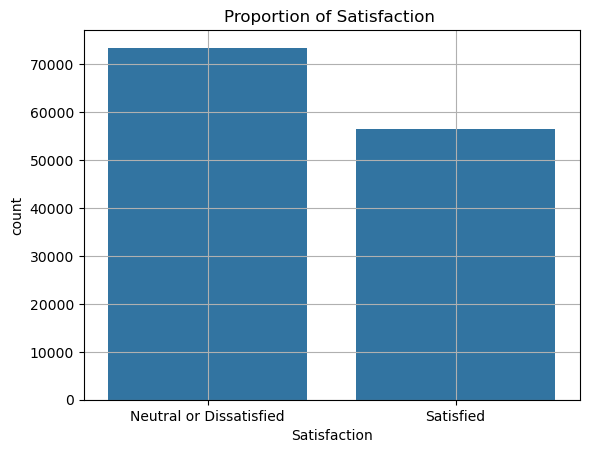

Satisfaction percentage:  43.44625808438558 %


In [118]:
# satisfaction_count.T.plot.bar(title="Satisfaction", legend=False);
sns.barplot(x=satisfaction_count.keys(), y=satisfaction_count)
plt.title("Proportion of Satisfaction ")
plt.xlabel('Satisfaction')
plt.grid(True)
plt.show()
print('Satisfaction percentage: ', 100*satisfaction_count["Satisfied"]/len(df["Satisfaction"]), '%')

Now that we have corrected  NAs in the data and gotten a general idea of how the labels look, let's look at the features. To do this, let's convert the objects-containing columns into numbers-containing columns.

In [119]:
from sklearn.preprocessing import LabelEncoder
numerical_col = df.select_dtypes(include = ['number']).columns
categorical_col = df.select_dtypes(exclude = ['number'] ).columns
label_encoder = LabelEncoder()
columns = df[categorical_col].apply(label_encoder.fit_transform)
df[list(columns.columns)] = columns              # appending the encoded columns back to the dataset
df = df.apply(pd.to_numeric, errors='coerce')
df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,1,48,0,0,0,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,0
1,2,0,35,1,0,0,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,1
2,3,1,41,1,0,0,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,1
3,4,1,50,1,0,0,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,1
4,5,0,49,1,0,0,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,1


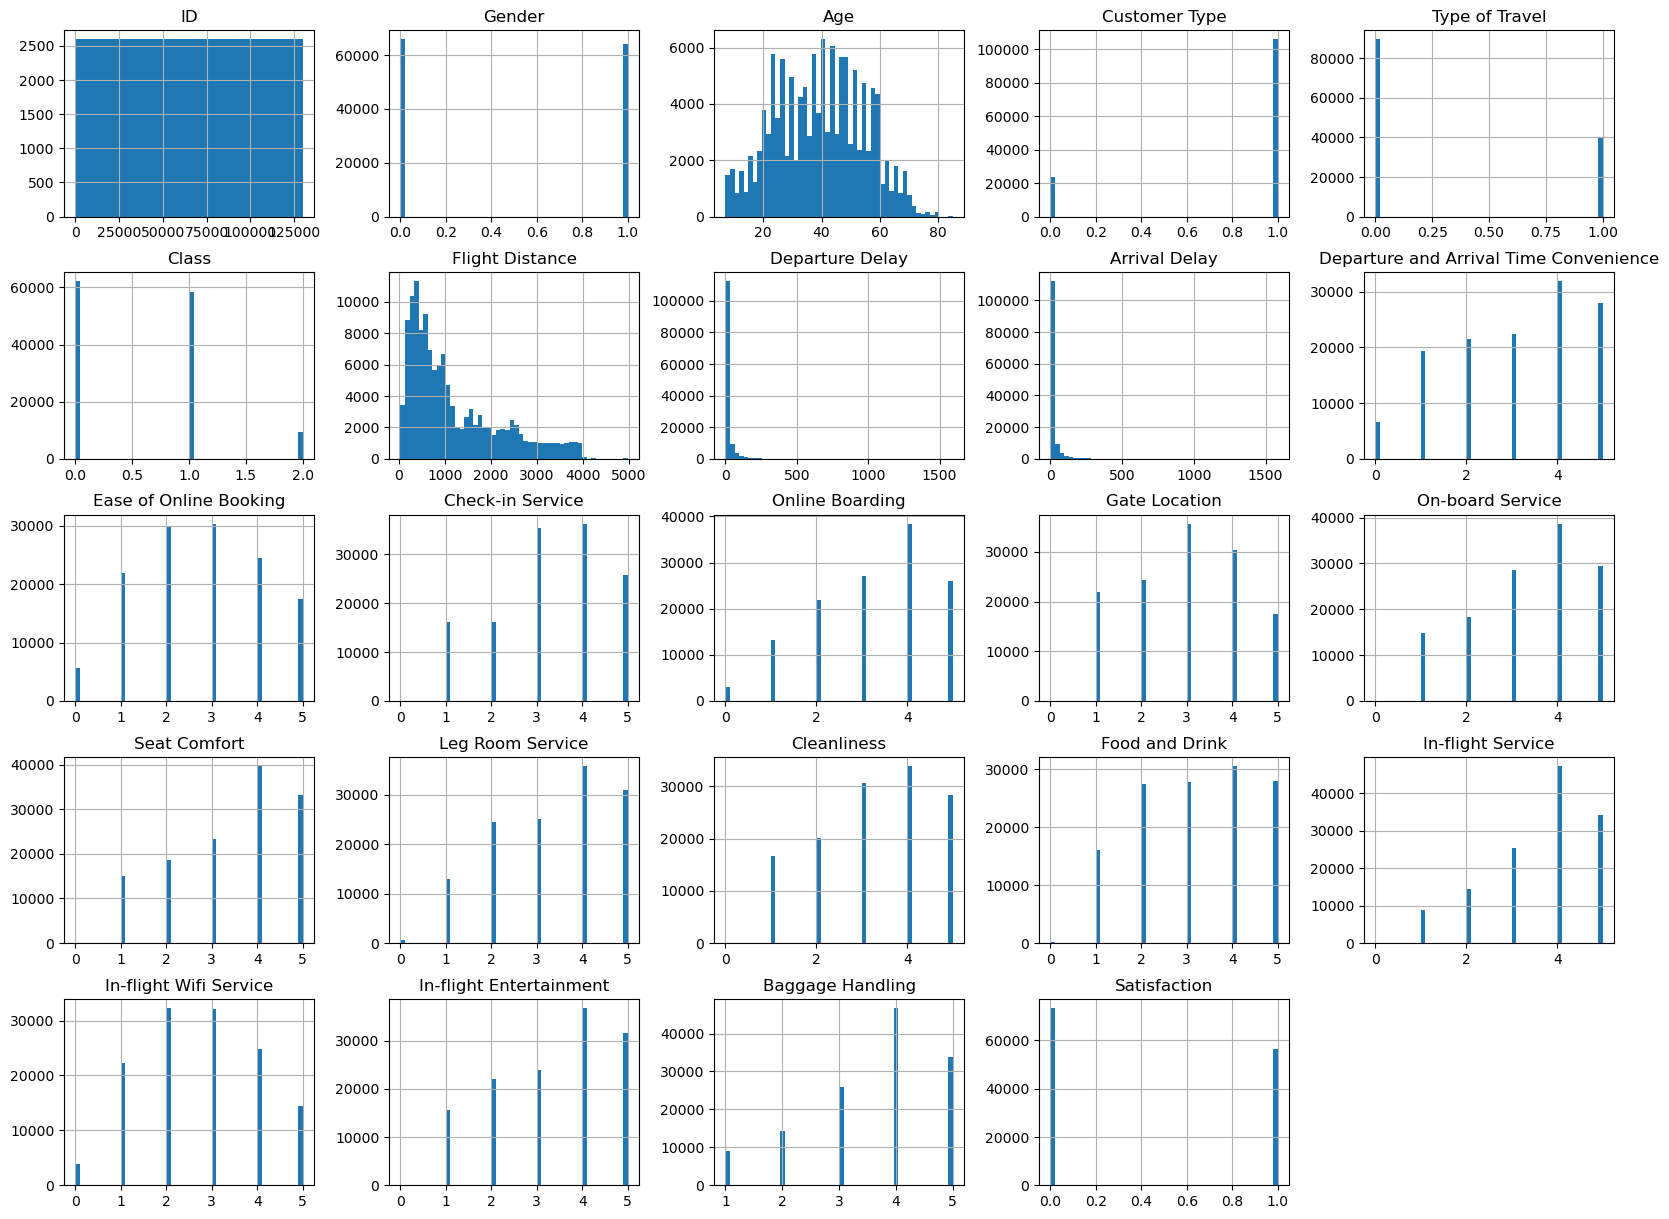

In [120]:
df.hist(bins=50, figsize=(20,15))
plt.show()

In [121]:
corr_matrix = df.corr(numeric_only=False)
corr_matrix["Satisfaction"].sort_values(ascending=False)

Satisfaction                              1.000000
Online Boarding                           0.501749
In-flight Entertainment                   0.398234
Seat Comfort                              0.348829
On-board Service                          0.322205
Leg Room Service                          0.312424
Cleanliness                               0.307035
Flight Distance                           0.298085
In-flight Wifi Service                    0.283460
Baggage Handling                          0.248680
In-flight Service                         0.244918
Check-in Service                          0.237252
Food and Drink                            0.211340
Customer Type                             0.186017
Ease of Online Booking                    0.168877
Age                                       0.134091
ID                                        0.013182
Gender                                    0.011236
Gate Location                            -0.002793
Departure Delay                

We can see that some features are negatively correlated to our labels and some categories have almost no impact on the labels' variance (ID, Gender, Gate Location, Departure Delay, Departure and Arrival Time Convenience, Arrival Delay).

Let's see if the categories are correlated as I suspect departure and arrival delay to be over 90% correlated.


In [122]:
corr_matrix_total = df.corr()
corr_matrix_total

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
ID,1.000000,-0.001361,0.020322,-0.001467,-0.000935,-0.104671,0.095504,-0.017643,-0.035405,-0.002192,...,0.055502,0.052164,0.044088,0.024048,-0.000510,0.078793,-0.023096,0.001620,0.074569,0.013182
Gender,-0.001361,1.000000,0.008996,0.030958,0.009503,-0.011574,0.003616,0.003491,0.001286,0.008995,...,0.006447,-0.030756,0.031047,0.002867,0.001730,0.038504,0.005901,0.003843,0.036356,0.011236
Age,0.020322,0.008996,1.000000,0.284172,-0.044808,-0.116921,0.099459,-0.009041,-0.011206,0.036960,...,0.057078,0.159136,0.039119,0.052565,0.023194,-0.051347,0.016116,0.074947,-0.047991,0.134091
Customer Type,-0.001467,0.030958,0.284172,1.000000,0.308236,-0.042994,0.226021,-0.003859,-0.004769,0.206873,...,0.054172,0.156239,0.046841,0.081302,0.056997,-0.023292,0.005757,0.106001,-0.024874,0.186017
Type of Travel,-0.000935,0.009503,-0.044808,0.308236,1.000000,0.486718,-0.266792,-0.005913,-0.005972,0.257102,...,-0.059794,-0.127717,-0.139612,-0.084615,-0.068986,-0.023538,-0.105865,-0.152936,-0.033012,-0.449861
Class,-0.104671,-0.011574,-0.116921,-0.042994,0.486718,1.000000,-0.426925,0.009530,0.014037,0.087152,...,-0.210649,-0.212334,-0.198825,-0.129623,-0.080773,-0.159285,-0.024962,-0.183162,-0.166588,-0.448193
Flight Distance,0.095504,0.003616,0.099459,0.226021,-0.266792,-0.426925,1.000000,0.002402,-0.001973,-0.018914,...,0.111194,0.157662,0.134533,0.095648,0.057066,0.059316,0.006701,0.130507,0.064855,0.298085
Departure Delay,-0.017643,0.003491,-0.009041,-0.003859,-0.005913,0.009530,0.002402,1.000000,0.959382,0.000778,...,-0.030486,-0.027999,0.014574,-0.014543,-0.029164,-0.054432,-0.015946,-0.027012,-0.004105,-0.050740
Arrival Delay,-0.035405,0.001286,-0.011206,-0.004769,-0.005972,0.014037,-0.001973,0.959382,1.000000,-0.001005,...,-0.034671,-0.030397,0.011384,-0.016547,-0.031685,-0.059685,-0.017762,-0.030183,-0.007997,-0.058145
Departure and Arrival Time Convenience,-0.002192,0.008995,0.036960,0.206873,0.257102,0.087152,-0.018914,0.000778,-0.001005,1.000000,...,0.067297,0.008666,0.010617,0.009862,0.000687,0.072195,0.344915,-0.008380,0.070833,-0.054270


They are indeed over 96% correlated. We could create one single column called "delay" computed by getting the mean of both columns.

We can also see that all of the "extra" services are highly correlated to each other (>60%): In-flight Entertainment, In-flight Wifi Service, In-flight Service, Food and Drink, Cleanliness, Seat Comfort, On-board Services

In [123]:
y = df['Satisfaction'].to_numpy()
X = df.drop(columns=['ID', 'Satisfaction'])


In [124]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [125]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score

def CVScores(modelused):
    CVS=cross_val_score(modelused, X_train, y_train, scoring="accuracy", cv=10)
    print(np.mean(CVS))
    print(CVS)
def modelFitPred(model, returnPred=False):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(model.score(X_test, y_test))
    print(classification_report(y_test, y_pred))
    CVScores(model)
    if returnPred == True:
        return y_pred

In [126]:
from sklearn.ensemble import RandomForestClassifier
modelFitPred(RandomForestClassifier())

0.9630428087465353
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14723
           1       0.97      0.94      0.96     11253

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976

0.962388299862295
[0.96294871 0.96631701 0.96419979 0.96217881 0.96217517 0.95861405
 0.96169394 0.96496631 0.96246391 0.95832531]


This is a very good score to begin, and there is not even any overfitting! Let's keep going and look at other models!

In [127]:
from sklearn.neighbors import KNeighborsClassifier
modelFitPred(KNeighborsClassifier())

0.7473821989528796
              precision    recall  f1-score   support

           0       0.76      0.81      0.78     14723
           1       0.73      0.67      0.70     11253

    accuracy                           0.75     25976
   macro avg       0.74      0.74      0.74     25976
weighted avg       0.75      0.75      0.75     25976

0.7489701515776452
[0.74747378 0.74853238 0.74920604 0.75603888 0.75582291 0.74167469
 0.74889317 0.75283927 0.74552454 0.74369586]


Let's do some quick feature engineering to improve KNN and see if that helps a little bit since the result is much lower than that of the random forest classifier.

Maximum KNN score on the test data: 74.98%, obtained at 10 neighbors
0.7474591931013242
              precision    recall  f1-score   support

           0       0.74      0.86      0.79     14723
           1       0.76      0.60      0.67     11253

    accuracy                           0.75     25976
   macro avg       0.75      0.73      0.73     25976
weighted avg       0.75      0.75      0.74     25976

0.7499807748042862
[0.74410548 0.74920604 0.74612646 0.75805986 0.75774783 0.74581328
 0.75245428 0.75216554 0.74494706 0.74918191]


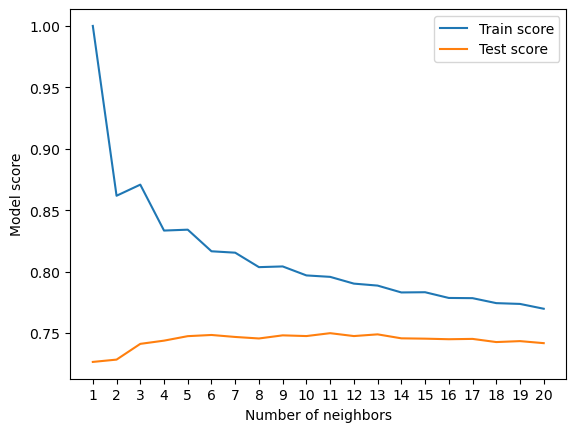

In [128]:
train_scores = []
test_scores = []
knn = KNeighborsClassifier()
neighbors = range(1, 21)

# Looping through different neighbors values
for i in neighbors:
    knn.set_params(n_neighbors = i)                  # setting neighbors' value
    knn.fit(X_train, y_train)                        # fitting
    train_scores.append(knn.score(X_train, y_train)) # updating the training scores
    test_scores.append(knn.score(X_test, y_test))    # Updating the test scores

plt.plot(neighbors, train_scores, label="Train score")
plt.plot(neighbors, test_scores, label="Test score")
plt.xticks(np.arange(1, 21, 1))
plt.xlabel("Number of neighbors")
plt.ylabel("Model score")
plt.legend()

print(f"Maximum KNN score on the test data: {max(test_scores)*100:.2f}%, obtained at {test_scores.index(max(test_scores))} neighbors")
modelFitPred(KNeighborsClassifier(n_neighbors=test_scores.index(max(test_scores))))

We managed to improve it by about 1%, which is really low.
We also see a large gap between the two scores, meaning that there is overfitting. This model is really not correct for this dataset. Let's keep looking for a few more!

In [129]:
from sklearn.linear_model import LogisticRegression
modelFitPred(LogisticRegression(max_iter=5000))

0.8743455497382199
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     14723
           1       0.87      0.84      0.85     11253

    accuracy                           0.87     25976
   macro avg       0.87      0.87      0.87     25976
weighted avg       0.87      0.87      0.87     25976

0.8742782034760406
[0.86815513 0.87441055 0.87498797 0.87710519 0.87372474 0.87160731
 0.87545717 0.88171319 0.87305101 0.87256978]


The result is much worse than that of the random forest classifier, let's try once more with another model

In [130]:
from sklearn.tree import DecisionTreeClassifier
modelFitPred(DecisionTreeClassifier())

0.9464890668309208
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     14723
           1       0.94      0.94      0.94     11253

    accuracy                           0.95     25976
   macro avg       0.95      0.95      0.95     25976
weighted avg       0.95      0.95      0.95     25976

0.9465468099151844
[0.94216149 0.94928303 0.9502454  0.94475989 0.94629451 0.94369586
 0.94831569 0.94889317 0.9466795  0.94513956]


Very good results! We have found 2 great candidate models. Let's optimize their hyperparameters to unlock their full potential and compare them!

In [146]:
from sklearn.model_selection import RandomizedSearchCV
# Different RandomForestClassifier hyperparameters
rf_grid = {"n_estimators": np.arange(10, 200, 45), "max_depth": [None, 3, 5, 10], "min_samples_split": np.arange(2, 20, 2),
           "min_samples_leaf": np.arange(1, 20, 2)}
RFCl = RandomForestClassifier()
# Setup randomized hyperparameter search for RandomForest (Grid search takes too long)
RF_RSCV = RandomizedSearchCV(RFCl, param_distributions=rf_grid, cv=5, n_jobs=-1, verbose=True)
RF_RSCV.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,RandomForestClassifier()
,param_distributions,"{'max_depth': [None, 3, ...], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), 'min_samples_split': array([ 2, 4..., 14, 16, 18]), 'n_estimators': array([ 10, ...00, 145, 190])}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [147]:
modelFitPred(RandomForestClassifier(n_estimators = RF_RSCV.best_params_["n_estimators"],
                                  max_depth = RF_RSCV.best_params_["max_depth"],
                                  min_samples_split = RF_RSCV.best_params_["min_samples_split"],
                                  min_samples_leaf = RF_RSCV.best_params_["min_samples_leaf"],))

0.9541884816753927
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     14723
           1       0.96      0.93      0.95     11253

    accuracy                           0.95     25976
   macro avg       0.95      0.95      0.95     25976
weighted avg       0.95      0.95      0.95     25976

0.95327411770514
[0.95342123 0.95650082 0.9559234  0.95332499 0.95120308 0.9493744
 0.95158807 0.95688162 0.95283927 0.95168431]


In [142]:
modelFitPred(RandomForestClassifier())

0.9634277794887589
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14723
           1       0.97      0.94      0.96     11253

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976

0.9625134303590072
[0.96131267 0.9670869  0.96391108 0.96227505 0.96227141 0.95890279
 0.96169394 0.96506256 0.9626564  0.9599615 ]


In [156]:
from sklearn.tree import DecisionTreeClassifier
dt_grid = { "criterion": ["gini", "entropy", "log_loss"],
            "splitter": ["best", "random"],
            "max_depth": [None, 3, 5, 10, 20, 30, 50],
            "min_samples_split": np.arange(2, 20, 1),
            "min_samples_leaf": np.arange(1, 20, 1),
            "max_features": [None, "sqrt", "log2"]}

DTCl = DecisionTreeClassifier(random_state=42)

DT_RSCV = RandomizedSearchCV(DTCl, param_distributions=dt_grid, n_iter=20, cv=10, random_state=42, n_jobs=-1, verbose=1)
tree.fit(X_train , y_train)
modelFitPred(DTCl)

0.9467970434246997
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     14723
           1       0.94      0.94      0.94     11253

    accuracy                           0.95     25976
   macro avg       0.95      0.95      0.95     25976
weighted avg       0.95      0.95      0.95     25976

0.9466430275922683
[0.94524107 0.94976422 0.95034164 0.94408623 0.94552454 0.94350337
 0.94831569 0.94918191 0.94725698 0.94321463]


In [157]:
modelFitPred(DecisionTreeClassifier(random_state=42))

0.9467970434246997
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     14723
           1       0.94      0.94      0.94     11253

    accuracy                           0.95     25976
   macro avg       0.95      0.95      0.95     25976
weighted avg       0.95      0.95      0.95     25976

0.9466430275922683
[0.94524107 0.94976422 0.95034164 0.94408623 0.94552454 0.94350337
 0.94831569 0.94918191 0.94725698 0.94321463]


I performed hyperparameter optimization using randomized cross-validation. The optimized model did not improve performance on the independent test set. This suggests that the default RandomForest and DecisionTree parameters already generalize well for this dataset, and further tuning did not provide additional benefit.

Based on these results, we will select the RandomForest model since its accuracy, precision, recall and f1 are higher in every category.